In [1]:
import torch, cv2
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Device: NVIDIA GeForce MX250


In [2]:
from ultralytics import YOLO
import cv2, numpy as np

DEVICE = 0 if torch.cuda.is_available() else "cpu"
model = YOLO("yolov8n-seg.pt").to(DEVICE)

VIDEO_IN  = "ssstwitter.com_1780947371266.mp4"
VIDEO_OUT = "seg_out.mp4"

cap = cv2.VideoCapture(VIDEO_IN)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25
writer = cv2.VideoWriter(VIDEO_OUT, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

def color_for(idx):
    rng = np.random.default_rng(idx * 7919)
    return tuple(int(c) for c in rng.integers(60, 255, 3))

while True:
    ok, frame = cap.read()
    if not ok: break

    res = model.predict(frame, conf=0.35, verbose=False, device=DEVICE)[0]
    overlay = frame.copy()

    if res.masks is not None:
        masks   = res.masks.data.cpu().numpy()
        classes = res.boxes.cls.cpu().numpy().astype(int)
        for i, m in enumerate(masks):
            m = cv2.resize(m, (w, h)) > 0.5
            overlay[m] = color_for(i)
        frame = cv2.addWeighted(overlay, 0.5, frame, 0.5, 0)

    writer.write(frame)

cap.release(); writer.release()
print("Saved:", VIDEO_OUT)

Saved: seg_out.mp4


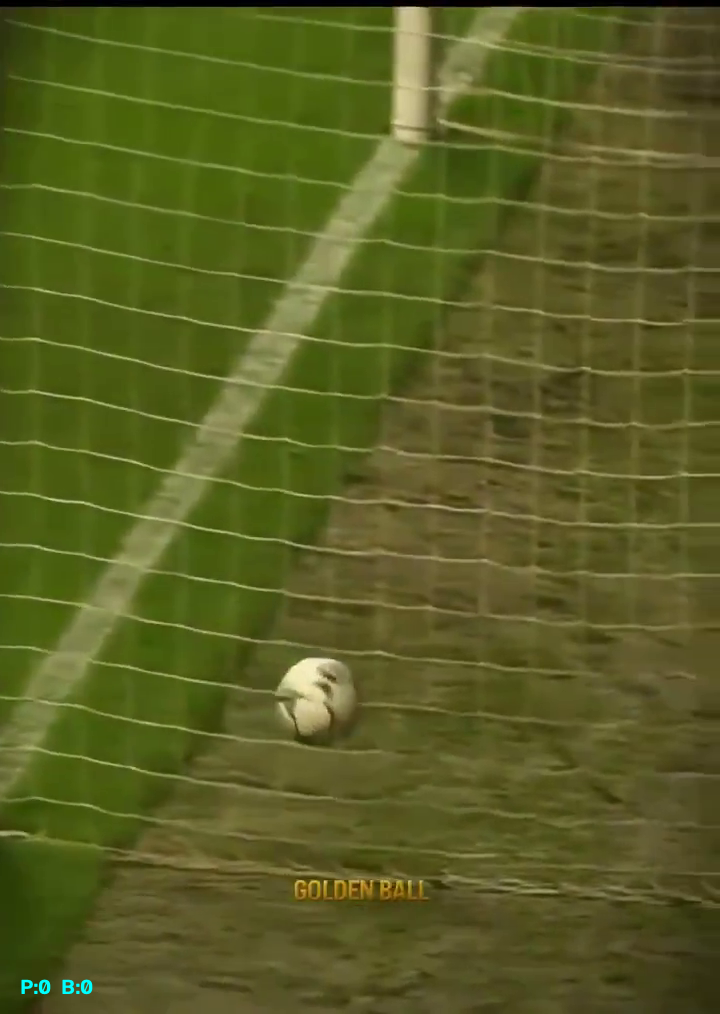


Обработано кадров:                886
Сумма детекций person по кадрам:  998
Сумма детекций ball   по кадрам:  713
Событий касания:                  9


In [3]:
from ultralytics import YOLO
import cv2, numpy as np, torch, time
from IPython.display import display, clear_output
from PIL import Image

DEVICE = 0 if torch.cuda.is_available() else "cpu"
model = YOLO("yolov8n-seg.pt").to(DEVICE)

VIDEO_IN  = "ssstwitter.com_1780947371266.mp4"
VIDEO_OUT = "seg_out.mp4"

# --- классы COCO ---
PERSON_ID = 0
BALL_ID   = 32

PERSON_CONF = 0.35
BALL_CONF   = 0.15     # мяч часто даёт низкий conf

CLASSES    = [PERSON_ID, BALL_ID]
IMGSZ      = 960       # ↑ для мелких объектов
PROCESS_EVERY = 2
IOU_THRESH = 0.005     # маленькое пересечение — уже касание
BALL_DILATE = 5        # пикселей дилатации маски мяча

cap = cv2.VideoCapture(VIDEO_IN)
w  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25
writer = cv2.VideoWriter(VIDEO_OUT, cv2.VideoWriter_fourcc(*"mp4v"),
                         fps / PROCESS_EVERY, (w, h))

def color_for(idx):
    rng = np.random.default_rng(abs(int(idx)) * 7919 + 1)   # фикс отрицательных tid
    return tuple(int(c) for c in rng.integers(60, 255, 3))

kernel = np.ones((BALL_DILATE, BALL_DILATE), np.uint8)

frame_idx = 0
last_notify = 0
notify_log = []
stats = {"frames": 0, "person": 0, "ball": 0}

while True:
    ok, frame = cap.read()
    if not ok:
        break
    frame_idx += 1
    if frame_idx % PROCESS_EVERY != 0:
        continue

    res = model.track(
        frame,
        persist=True,
        conf=min(PERSON_CONF, BALL_CONF),   # низкий порог, раздельно режем ниже
        classes=CLASSES,
        verbose=False,
        device=DEVICE,
        imgsz=IMGSZ,
    )[0]
    stats["frames"] += 1

    vis = frame.copy()
    person_data = []   # (tid, mask)
    ball_data   = []   # (mask,)

    if res.masks is not None and res.boxes is not None:
        masks   = res.masks.data.cpu().numpy()
        classes = res.boxes.cls.cpu().numpy().astype(int)
        confs   = res.boxes.conf.cpu().numpy()
        tids    = (res.boxes.id.cpu().numpy().astype(int)
                   if res.boxes.id is not None
                   else np.full(len(classes), -1))

        for m, c, t, cf in zip(masks, classes, tids, confs):
            # раздельные пороги
            if c == PERSON_ID and cf < PERSON_CONF:
                continue
            if c == BALL_ID and cf < BALL_CONF:
                continue

            mm = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST) > 0.5

            if c == PERSON_ID:
                person_data.append((int(t), mm))
            elif c == BALL_ID:
                # дилатация — компенсация грубых границ сегментации
                mm_d = cv2.dilate(mm.astype(np.uint8), kernel, iterations=1).astype(bool)
                ball_data.append(mm_d)

    stats["person"] += len(person_data)
    stats["ball"]   += len(ball_data)

    # --- визуализация ---
    for tid, pm in person_data:
        col = color_for(tid)
        vis[pm] = (vis[pm] * 0.5 + np.array(col) * 0.5).astype(np.uint8)
    for bm in ball_data:
        vis[bm] = (vis[bm] * 0.5 + np.array([0, 0, 255]) * 0.5).astype(np.uint8)

    # --- поиск касания ---
    touch_events = []
    for tid, pm in person_data:
        for bm in ball_data:
            inter = np.logical_and(pm, bm).sum()
            union = np.logical_or(pm, bm).sum()
            iou = inter / union if union else 0.0
            if iou > IOU_THRESH:
                touch_events.append((tid, iou))

    if touch_events:
        txt = " | ".join(f"ID{tid} IoU={iou:.3f}" for tid, iou in touch_events)
        cv2.putText(vis, "TOUCH: " + txt, (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 3)

    # счётчики прямо в кадре — сразу видно, что детектится
    cv2.putText(vis, f"P:{len(person_data)}  B:{len(ball_data)}",
                (20, h - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

    # --- уведомление в Jupyter ---
    if touch_events and time.time() - last_notify > 0.7:
        for tid, iou in touch_events:
            msg = f"[frame {frame_idx}] ⚽ Игрок ID={tid} коснулся мяча (IoU={iou:.3f})"
            print(msg)
            notify_log.append((frame_idx, tid, float(iou)))
        last_notify = time.time()

    writer.write(vis)

    if (frame_idx // PROCESS_EVERY) % 15 == 0:
        img = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
        clear_output(wait=True)
        display(Image.fromarray(img))

cap.release(); writer.release()

print(f"\nОбработано кадров:                {stats['frames']}")
print(f"Сумма детекций person по кадрам:  {stats['person']}")
print(f"Сумма детекций ball   по кадрам:  {stats['ball']}")
print(f"Событий касания:                  {len(notify_log)}")

In [2]:
import urllib.request, os

os.makedirs("models", exist_ok=True)

POSE_URL = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task"
HAND_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"

for url, name in [(POSE_URL, "models/pose_landmarker.task"),
                  (HAND_URL, "models/hand_landmarker.task")]:
    if not os.path.exists(name):
        print(f"Downloading {name} ...")
        urllib.request.urlretrieve(url, name)
    print(f"OK: {name} ({os.path.getsize(name)//1024} KB)")

OK: models/pose_landmarker.task (9177 KB)
OK: models/hand_landmarker.task (7635 KB)


In [3]:
import urllib.request, os
HAND_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
os.makedirs("models", exist_ok=True)
if not os.path.exists("models/hand_landmarker.task"):
    urllib.request.urlretrieve(HAND_URL, "models/hand_landmarker.task")
print("OK:", os.path.getsize("models/hand_landmarker.task")//1024, "KB")

OK: 7635 KB


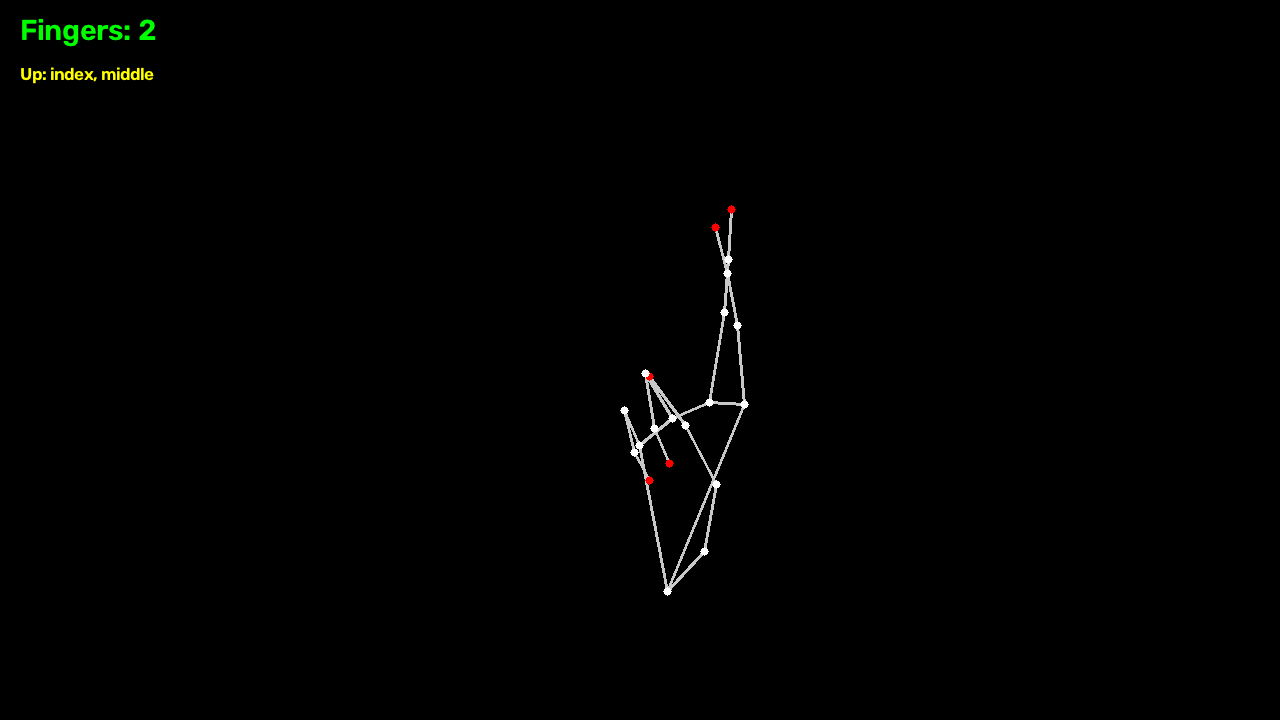

Кадров: 452  Время: 21.9s

Распределение:
  0: 89 кадров
  1: 60 кадров
  2: 170 кадров
  3: 45 кадров
  4: 47 кадров
  5: 41 кадров


In [10]:
import cv2, numpy as np, time
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from IPython.display import display, clear_output
from PIL import Image
from collections import deque, Counter

VIDEO_IN       = "Counting to ten in Chinese with one hand.mp4"
VIDEO_OUT_SKEL = "landmarks_hand.mp4"
VIDEO_OUT_MIX  = "landmarks_hand_overlay.mp4"
MODEL_PATH     = "models/hand_landmarker.task"

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),
    (0,17),
]

def _angle(a, b, c):
    v1 = a - b; v2 = c - b
    cos = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6)
    return np.arccos(np.clip(cos, -1, 1))

def draw_hand(canvas, landmarks_norm, w, h, up_names=None):
    pts = [(int(lm.x * w), int(lm.y * h)) for lm in landmarks_norm]
    for a, b in HAND_CONNECTIONS:
        cv2.line(canvas, pts[a], pts[b], (200, 200, 200), 2)
    for i, (x, y) in enumerate(pts):
        color = (0, 0, 255) if i in (4, 8, 12, 16, 20) else (255, 255, 255)
        cv2.circle(canvas, (x, y), 4, color, -1)

# --- улучшенный подсчёт ---
TIP_IDX = {"thumb": 4, "index": 8, "middle": 12, "ring": 16, "pinky": 20}

def count_fingers(landmarks_norm, w, h):
    pts = np.array([(lm.x * w, lm.y * h) for lm in landmarks_norm])
    wrist = pts[0]
    up = []

    # 4 пальца: расстояние + угол
    fingers = [("index", 5, 6, 8),
               ("middle", 9, 10, 12),
               ("ring", 13, 14, 16),
               ("pinky", 17, 18, 20)]
    for name, mcp, pip, tip in fingers:
        d_pip = np.linalg.norm(pts[pip] - wrist)
        d_tip = np.linalg.norm(pts[tip] - wrist)
        ang   = _angle(pts[mcp], pts[pip], pts[tip])
        # чуть мягче, чем было
        if d_tip > d_pip * 1.03 and ang > np.deg2rad(145):
            up.append(name)

    # большой: distance + угол в CMC (1-2-4)
    d_tip_pinky = np.linalg.norm(pts[4] - pts[17])
    d_mcp_pinky = np.linalg.norm(pts[2] - pts[17])
    ang_cmc     = _angle(pts[1], pts[2], pts[4])
    if d_tip_pinky > d_mcp_pinky * 1.10 and ang_cmc > np.deg2rad(150):
        up.append("thumb")

    return len(up), up

# --- landmarker ---
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

cap = cv2.VideoCapture(VIDEO_IN)
w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25

writer_skel = cv2.VideoWriter(VIDEO_OUT_SKEL, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
writer_mix  = cv2.VideoWriter(VIDEO_OUT_MIX,  cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

SMOOTH_WIN = 15                             # было 7
history_n  = deque(maxlen=SMOOTH_WIN)
history_up = deque(maxlen=SMOOTH_WIN)       # для голосования по именам

frame_idx  = 0
counts_log = []
t0 = time.time()

with HandLandmarker.create_from_options(options) as landmarker:
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        res = landmarker.detect_for_video(mp_img, int(frame_idx * 1000 / fps))

        canvas_skel = np.zeros_like(frame)
        canvas_mix  = frame.copy()

        if res.hand_landmarks:
            hand = res.hand_landmarks[0]     # работаем с первой рукой
            n_raw, up_raw = count_fingers(hand, w, h)

            history_n.append(n_raw)
            history_up.append(tuple(sorted(up_raw)))

            # сглаживание: берём моду по количеству
            n_smooth = Counter(history_n).most_common(1)[0][0]

            # для отображения имён — самое частое сочетание в окне
            up_smooth = Counter(history_up).most_common(1)[0][0]

            draw_hand(canvas_skel, hand, w, h)
            draw_hand(canvas_mix,  hand, w, h)

            txt1 = f"Fingers: {n_smooth}"
            txt2 = f"Up: {', '.join(up_smooth) if up_smooth else '-'}"
            for c in (canvas_skel, canvas_mix):
                cv2.putText(c, txt1, (20, 40),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)
                cv2.putText(c, txt2, (20, 80),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

            counts_log.append((frame_idx, n_smooth))
        else:
            history_n.clear()
            history_up.clear()

        writer_skel.write(canvas_skel)
        writer_mix.write(canvas_mix)

        if frame_idx % 10 == 0:
            img = cv2.cvtColor(canvas_skel, cv2.COLOR_BGR2RGB)
            clear_output(wait=True)
            display(Image.fromarray(img))

cap.release(); writer_skel.release(); writer_mix.release()

print(f"Кадров: {frame_idx}  Время: {time.time()-t0:.1f}s")
if counts_log:
    print("\nРаспределение:")
    for cnt, freq in sorted(Counter(c for _, c in counts_log).items()):
        print(f"  {cnt}: {freq} кадров")

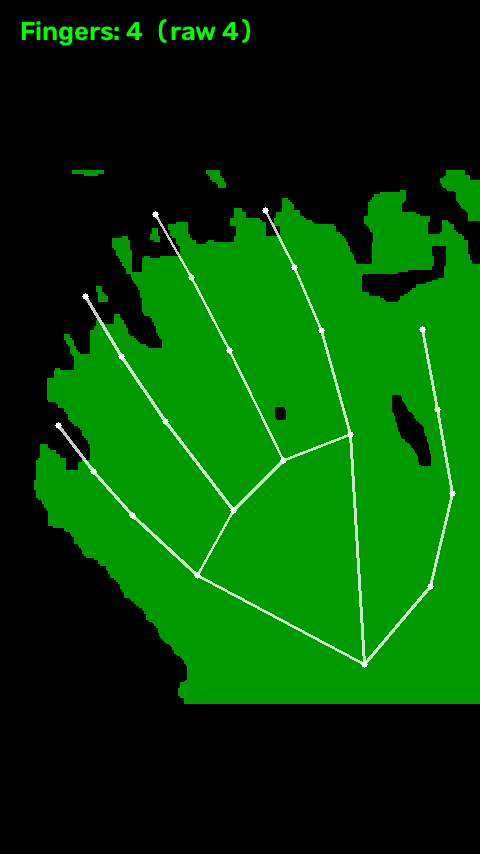

Кадров: 244  Время: 15.4s

Сглаженное распределение:
  1 пальцев: 61 кадров
  2 пальцев: 130 кадров
  3 пальцев: 33 кадров
  4 пальцев: 16 кадров
  5 пальцев: 4 кадров


In [4]:
import cv2, numpy as np, time
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d
from IPython.display import display, clear_output
from PIL import Image
from collections import deque, Counter

VIDEO_IN       = "polydactyly.mp4"           # ← твой файл
VIDEO_OUT_SKEL = "landmarks_hand1.mp4"
VIDEO_OUT_MIX  = "landmarks_hand_overlay1.mp4"
MODEL_PATH     = "models/hand_landmarker.task"

# ---- HSV диапазон кожи (подстрой под своё видео) ----
# Если кожа плохо ловится — расширь H, подними S_min/V_min.
SKIN_LOWER = np.array([0,  30,  60], dtype=np.uint8)
SKIN_UPPER = np.array([25, 180, 255], dtype=np.uint8)

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),(9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),(0,17),
]

def draw_hand(canvas, landmarks_norm, w, h):
    pts = [(int(lm.x * w), int(lm.y * h)) for lm in landmarks_norm]
    for a, b in HAND_CONNECTIONS:
        cv2.line(canvas, pts[a], pts[b], (200, 200, 200), 2)
    for i, (x, y) in enumerate(pts):
        cv2.circle(canvas, (x, y), 3, (255, 255, 255), -1)

def get_roi_from_landmarks(hand_lms, w, h, pad=40):
    """bbox вокруг лендмарков с отступом — область для HSV."""
    xs = [lm.x * w for lm in hand_lms]
    ys = [lm.y * h for lm in hand_lms]
    x1 = max(0, int(min(xs)) - pad)
    y1 = max(0, int(min(ys)) - pad)
    x2 = min(w, int(max(xs)) + pad)
    y2 = min(h, int(max(ys)) + pad)
    return x1, y1, x2, y2

def count_fingers_silhouette(frame_bgr, roi):
    """Считает пики контура руки. Возвращает (N, маска, контур)."""
    x1, y1, x2, y2 = roi
    crop = frame_bgr[y1:y2, x1:x2]
    if crop.size == 0:
        return 0, None, None

    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, SKIN_LOWER, SKIN_UPPER)

    # чистка
    k = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k, iterations=1)

    # берём самый крупный контур
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return 0, mask, None
    cnt = max(cnts, key=cv2.contourArea)
    if cv2.contourArea(cnt) < 500:
        return 0, mask, None

    # сглаживаем контур
    eps = 0.002 * cv2.arcLength(cnt, True)
    cnt_s = cv2.approxPolyDP(cnt, eps, True)

    pts = cnt_s.reshape(-1, 2).astype(np.float32)
    M = cv2.moments(cnt_s)
    if M["m00"] == 0:
        return 0, mask, cnt
    cx, cy = M["m10"] / M["m00"], M["m01"] / M["m00"]

    # радиальный профиль
    d = np.sqrt((pts[:, 0] - cx) ** 2 + (pts[:, 1] - cy) ** 2)
    d = uniform_filter1d(d, size=7)

    # проминенция ~ 10% от размаха — устойчиво к шуму
    prominence = max(5, (d.max() - d.min()) * 0.10)
    peaks, _ = find_peaks(
        d,
        prominence=prominence,
        distance=max(5, len(d) // 40),
    )
    return len(peaks), mask, cnt

# ---- MediaPipe landmarker ----
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.4,
    min_hand_presence_confidence=0.4,
    min_tracking_confidence=0.4,
)

cap = cv2.VideoCapture(VIDEO_IN)
w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25

writer_skel = cv2.VideoWriter(VIDEO_OUT_SKEL, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
writer_mix  = cv2.VideoWriter(VIDEO_OUT_MIX,  cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

SMOOTH_WIN = 12
hist_count = deque(maxlen=SMOOTH_WIN)

frame_idx = 0
counts_log = []
t0 = time.time()

with HandLandmarker.create_from_options(options) as landmarker:
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        res = landmarker.detect_for_video(mp_img, int(frame_idx * 1000 / fps))

        canvas_skel = np.zeros_like(frame)
        canvas_mix  = frame.copy()

        if res.hand_landmarks:
            hand = res.hand_landmarks[0]
            draw_hand(canvas_skel, hand, w, h)
            draw_hand(canvas_mix,  hand, w, h)

            roi = get_roi_from_landmarks(hand, w, h)
            n_raw, mask_local, cnt_local = count_fingers_silhouette(frame, roi)

            if mask_local is not None:
                # накладываем маску на оба холста (для контроля)
                x1, y1, x2, y2 = roi
                sub_sk = canvas_skel[y1:y2, x1:x2]
                sub_mx = canvas_mix[y1:y2, x1:x2]
                m3 = cv2.cvtColor(mask_local, cv2.COLOR_GRAY2BGR)
                tint = np.zeros_like(m3); tint[..., 1] = 255   # зелёный
                overlay = (m3 > 0) & (tint > 0)
                sub_sk[overlay] = (sub_sk[overlay] * 0.4 + tint[overlay] * 0.6).astype(np.uint8)
                sub_mx[overlay] = (sub_mx[overlay] * 0.6 + tint[overlay] * 0.4).astype(np.uint8)
                cv2.rectangle(canvas_mix, (x1, y1), (x2, y2), (0, 255, 255), 1)

            hist_count.append(n_raw)
            n_smooth = Counter(hist_count).most_common(1)[0][0]

            for c in (canvas_skel, canvas_mix):
                cv2.putText(c, f"Fingers: {n_smooth}  (raw {n_raw})", (20, 40),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

            counts_log.append((frame_idx, n_smooth, n_raw))
        else:
            hist_count.clear()

        writer_skel.write(canvas_skel)
        writer_mix.write(canvas_mix)

        if frame_idx % 10 == 0:
            img = cv2.cvtColor(canvas_skel, cv2.COLOR_BGR2RGB)
            clear_output(wait=True)
            display(Image.fromarray(img))

cap.release(); writer_skel.release(); writer_mix.release()

print(f"Кадров: {frame_idx}  Время: {time.time()-t0:.1f}s")
if counts_log:
    print("\nСглаженное распределение:")
    for cnt, freq in sorted(Counter(c for _, c, _ in counts_log).items()):
        print(f"  {cnt} пальцев: {freq} кадров")